# GO enrichment results, exploratory data analysis

Generic and species-agnostic. Every section below reads only from the
fixed output schema `enrichment.output.write_results()` always produces
(`go_id, class, population, observed, expected, fold_enrichment, p_value,
q_value, significance`), plus, optionally, an `.obo` file for GO term
names and a second results file for a full-GO vs GO-slim comparison.
Point the Configuration cell at any real run's output and everything
below works, regardless of species, metric, or labeling strategy.

Per the main README's language-constraint principle (section 4): results
at the p<0.01 uncorrected threshold should be read as genes that *tended
to include* a term, not as statistically significant findings. This
notebook is for exploration and sanity-checking, not for generating
publication-ready significance claims on its own.

In [1]:
# ---------------------------------------------------------------------------
# Configuration -- the only cell that needs editing to point this notebook
# at a different run. Everything below is generic.
# ---------------------------------------------------------------------------

# Required: path to a summary.*.all.tsv file, e.g.
# "../results/GO/summary.CR_3D.PR_gene.all.tsv"
RESULTS_ALL_TSV = "../results/GO/summary.CR_3D.PR_gene.all.tsv"

# Optional: a second results file for the SAME labeled genes, to compare
# against the first (e.g. the GO-slim run of the same dataset). Set to
# None to skip the comparison section entirely.
RESULTS_ALL_TSV_COMPARE = "../results/GO_slim/summary.CR_3D.PR_gene.all.tsv"
COMPARE_LABEL_PRIMARY = "full-GO"
COMPARE_LABEL_SECONDARY = "GO-slim"

# Optional: path to the .obo file the run's .godb was built from, for GO
# term name/namespace lookup. Set to None to skip name lookup (tables
# will show go_id only).
OBO_PATH = "../data/go_reference/go-basic.obo"

# Which column defines "significant" for this notebook's highlighting --
# should match whatever --thresh-type the run actually used. The
# 'significance' column already reflects this; this only controls the
# volcano plot's y-axis and the near-miss calculation below.
SIG_COL = "p_value"  # or "q_value"
SIG_THRESH = 0.01

# A term with SIG_COL between SIG_THRESH and SIG_THRESH * NEAR_MISS_MULTIPLIER
# is flagged as a near miss, worth a second look rather than silently
# dropped once significance filtering happens.
NEAR_MISS_MULTIPLIER = 3

# How many top terms per class to show in the summary table.
TOP_N = 15

In [2]:
# RESULTS_ALL_TSV = "../results/GO/summary.CR_3D.TPM.all.tsv"
# RESULTS_ALL_TSV_COMPARE = "../results/GO_slim/summary.CR_3D.TPM.all.tsv"
# COMPARE_LABEL_PRIMARY = "full-GO"
# COMPARE_LABEL_SECONDARY = "GO-slim"
# OBO_PATH = "../data/go_reference/go-basic.obo"

In [3]:
RESULTS_ALL_TSV = "../results/GO/summary.CR_3D.PR_gene_cluster.all.tsv"
RESULTS_ALL_TSV_COMPARE = "../results/GO_slim/summary.CR_3D.PR_gene_cluster.all.tsv"
COMPARE_LABEL_PRIMARY = "full-GO"
COMPARE_LABEL_SECONDARY = "GO-slim"
OBO_PATH = "../data/go_reference/go-basic.obo"

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(RESULTS_ALL_TSV, sep="\t", comment="#")
print(f"Loaded {len(df)} (class, GO term) rows from {RESULTS_ALL_TSV}")
print(f"Classes present: {sorted(df['class'].unique())}")

compare_df = None
if RESULTS_ALL_TSV_COMPARE:
    compare_df = pd.read_csv(RESULTS_ALL_TSV_COMPARE, sep="\t", comment="#")
    print(f"Loaded {len(compare_df)} rows from {RESULTS_ALL_TSV_COMPARE} for comparison")

df.head()

Loaded 8169 (class, GO term) rows from ../results/GO/summary.CR_3D.PR_gene_cluster.all.tsv
Classes present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Loaded 602 rows from ../results/GO_slim/summary.CR_3D.PR_gene_cluster.all.tsv for comparison


,go_id,class,population,observed,expected,fold_enrichment,p_value,q_value,significance
0,GO:0003674,3,530,51,48.107692,0.082563,0.478673,1.0,False
1,GO:0016491,3,42,5,3.812308,0.318234,0.580629,1.0,False
2,GO:0003824,3,229,19,20.786154,-0.123412,0.671975,1.0,False
3,GO:0008150,3,321,26,29.136923,-0.158573,0.497068,1.0,False
4,GO:0009987,3,301,22,27.321538,-0.300266,0.219278,1.0,False


## GO term names

`write_results()`'s output only carries `go_id`. This section joins in
human-readable term names and namespaces from the `.obo` file, if given,
so every table below is actually readable rather than a wall of `GO:xxxxxxx`
identifiers.

In [5]:
godag = None
if OBO_PATH:
    from goatools.obo_parser import GODag
    godag = GODag(OBO_PATH)

def add_term_names(frame):
    frame = frame.copy()
    if godag is None:
        frame["go_name"] = frame["go_id"]
        frame["go_namespace"] = ""
        return frame
    frame["go_name"] = frame["go_id"].apply(
        lambda g: godag[g].name if g in godag else "(obsolete or not in this obo)"
    )
    frame["go_namespace"] = frame["go_id"].apply(
        lambda g: godag[g].namespace if g in godag else ""
    )
    return frame

df = add_term_names(df)
if compare_df is not None:
    compare_df = add_term_names(compare_df)

df.head()

../data/go_reference/go-basic.obo: fmt(1.2) rel(2026-07-26) 41,378 Terms


,go_id,class,population,observed,expected,fold_enrichment,p_value,q_value,significance,go_name,go_namespace
0,GO:0003674,3,530,51,48.107692,0.082563,0.478673,1.0,False,molecular_function,molecular_function
1,GO:0016491,3,42,5,3.812308,0.318234,0.580629,1.0,False,oxidoreductase activity,molecular_function
2,GO:0003824,3,229,19,20.786154,-0.123412,0.671975,1.0,False,catalytic activity,molecular_function
3,GO:0008150,3,321,26,29.136923,-0.158573,0.497068,1.0,False,biological_process,biological_process
4,GO:0009987,3,301,22,27.321538,-0.300266,0.219278,1.0,False,cellular process,biological_process


## Summary counts per class

A sanity check before anything else: does the number of significant terms
per class look plausible, or is something suspicious (e.g. every row
identically significant, or zero rows tested at all)?

In [6]:
summary_rows = []
for cls, cls_df in df.groupby("class"):
    n_sig = int(cls_df["significance"].sum())
    n_over = int((cls_df["significance"] & (cls_df["fold_enrichment"] > 0)).sum())
    n_under = int((cls_df["significance"] & (cls_df["fold_enrichment"] < 0)).sum())
    summary_rows.append({
        "class": cls,
        "n_terms_tested": len(cls_df),
        "n_significant": n_sig,
        "n_over": n_over,
        "n_under": n_under,
        "min_p_value": cls_df["p_value"].min(),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if summary_df["n_significant"].sum() == 0:
    print(
        "No significant terms in any class. Before concluding this is a "
        "real absence of signal, check the min_p_value column above and "
        "the near-miss section below -- if the minimum p_value is close "
        "to the threshold rather than close to 1.0, a coarser vocabulary "
        "(e.g. GO-slim) may simply not be isolating a real, narrower "
        "signal visible in a finer one, not a broken run."
    )

,class,n_terms_tested,n_significant,n_over,n_under,min_p_value
0,1,1167,2,2,0,0.006995
1,2,1167,1,0,1,0.004638
2,3,1167,0,0,0,0.015773
3,4,1167,0,0,0,0.011990
4,5,1167,3,0,3,0.003019
5,6,1167,10,10,0,0.000009
6,7,1167,0,0,0,0.036990


## Top terms per class

Sorted by p-value, not filtered to significance only, so a near-miss term
is still visible here even before the dedicated near-miss section below.

In [7]:
display_cols = ["go_id", "go_name", "go_namespace", "population", "observed",
                 "expected", "fold_enrichment", "p_value", "q_value", "significance"]

for cls, cls_df in df.groupby("class"):
    print(f"\n--- class: {cls} ---")
    display(cls_df.sort_values("p_value").head(TOP_N)[display_cols])


--- class: 1 ---


,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
5904,GO:0016301,kinase activity,molecular_function,40,13,5.415385,1.125819,0.006995,1.0,True
5905,GO:0016773,"phosphotransferase activity, alcohol group as ...",molecular_function,35,12,4.738462,1.179776,0.008036,1.0,True
6536,GO:0022607,cellular component assembly,biological_process,16,7,2.166154,1.337269,0.013361,1.0,False
6261,GO:0016043,cellular component organization,biological_process,25,9,3.384615,1.189478,0.013545,1.0,False
5917,GO:0016772,"transferase activity, transferring phosphorus-...",molecular_function,43,13,5.821538,1.037258,0.015642,1.0,False
5878,GO:0016740,transferase activity,molecular_function,67,17,9.070769,0.837823,0.018930,1.0,False
5885,GO:0071840,cellular component organization or biogenesis,biological_process,34,10,4.603077,0.973212,0.030574,1.0,False
5902,GO:0004672,protein kinase activity,molecular_function,30,9,4.061538,0.982352,0.039004,1.0,False
6740,GO:0022618,protein-RNA complex assembly,biological_process,4,3,0.541538,1.375629,0.040169,1.0,False
6739,GO:0071826,protein-RNA complex organization,biological_process,4,3,0.541538,1.375629,0.040169,1.0,False



--- class: 2 ---


,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
3505,GO:0009987,cellular process,biological_process,301,1,6.02,-1.811471,0.004638,1.0,True
3729,GO:0005694,chromosome,cellular_component,10,2,0.20,1.321928,0.020985,1.0,False
3612,GO:1990234,transferase complex,cellular_component,10,2,0.20,1.321928,0.020985,1.0,False
3504,GO:0008150,biological_process,biological_process,321,2,6.42,-1.306457,0.021750,1.0,False
4132,GO:0098687,chromosomal region,cellular_component,1,1,0.02,0.971431,0.038860,1.0,False
4128,GO:0000779,"condensed chromosome, centromeric region",cellular_component,1,1,0.02,0.971431,0.038860,1.0,False
4134,GO:0000775,"chromosome, centromeric region",cellular_component,1,1,0.02,0.971431,0.038860,1.0,False
4133,GO:0000444,MIS12/MIND type complex,cellular_component,1,1,0.02,0.971431,0.038860,1.0,False
3619,GO:1902911,protein kinase complex,cellular_component,1,1,0.02,0.971431,0.038860,1.0,False
3617,GO:0005956,protein kinase CK2 complex,cellular_component,1,1,0.02,0.971431,0.038860,1.0,False



--- class: 3 ---


...

,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
1194,GO:0003735,structural constituent of ribosome,molecular_function,37,1,9.335385,-2.369520,0.003019,1.0,True
1189,GO:0005840,ribosome,cellular_component,36,1,9.083077,-2.333864,0.003039,1.0,True
1311,GO:0140657,ATP-dependent activity,molecular_function,45,3,11.353846,-1.626888,0.009326,1.0,True
1232,GO:0032555,purine ribonucleotide binding,molecular_function,111,15,28.006154,-0.858287,0.011067,1.0,False
1245,GO:0035639,purine ribonucleoside triphosphate binding,molecular_function,111,15,28.006154,-0.858287,0.011067,1.0,False
1191,GO:0005198,structural molecule activity,molecular_function,57,5,14.381538,-1.358165,0.012631,1.0,False
1243,GO:0043168,anion binding,molecular_function,124,18,31.286154,-0.764916,0.015268,1.0,False
1185,GO:0043228,membraneless organelle,cellular_component,62,6,15.643077,-1.249495,0.016726,1.0,False
1184,GO:0043232,intracellular membraneless organelle,cellular_component,62,6,15.643077,-1.249495,0.016726,1.0,False
1328,GO:0017111,ribonucleoside triphosphate phosphatase activity,molecular_function,48,4,12.110769,-1.390752,0.019302,1.0,False



--- class: 6 ---


,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
4695,GO:0003735,structural constituent of ribosome,molecular_function,37,14,3.130769,1.860480,0.000009,0.009540,True
4690,GO:0005840,ribosome,cellular_component,36,13,3.046154,1.790804,0.000030,0.009540,True
4696,GO:0160307,protein biosynthetic process,biological_process,49,15,4.146154,1.636505,0.000033,0.009540,True
4697,GO:0006412,translation,biological_process,49,15,4.146154,1.636505,0.000033,0.009540,True
4692,GO:0005198,structural molecule activity,molecular_function,57,15,4.823077,1.458218,0.000147,0.034400,True
4685,GO:0043232,intracellular membraneless organelle,cellular_component,62,14,5.246154,1.263922,0.001029,0.171518,True
4686,GO:0043228,membraneless organelle,cellular_component,62,14,5.246154,1.263922,0.001029,0.171518,True
4688,GO:0010467,gene expression,biological_process,92,16,7.784615,0.952484,0.005813,0.753205,True
4691,GO:0009059,macromolecule biosynthetic process,biological_process,92,16,7.784615,0.952484,0.005813,0.753205,True
4676,GO:0019538,protein metabolic process,biological_process,116,19,9.815385,0.886915,0.006454,0.753205,True



--- class: 7 ---


,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
2356,GO:0005840,ribosome,cellular_component,36,18,9.692308,0.829426,0.036990,1.0,False
2361,GO:0003735,structural constituent of ribosome,molecular_function,37,18,9.961538,0.793549,0.039513,1.0,False
2364,GO:0009058,biosynthetic process,biological_process,112,42,30.153846,0.464926,0.048868,1.0,False
2409,GO:0000166,nucleotide binding,molecular_function,127,46,34.192308,0.417401,0.059521,1.0,False
2400,GO:1901265,nucleoside phosphate binding,molecular_function,128,46,34.461538,0.406406,0.060854,1.0,False
2407,GO:1901363,heterocyclic compound binding,molecular_function,129,46,34.730769,0.395494,0.076217,1.0,False
2415,GO:0017076,purine nucleotide binding,molecular_function,116,42,31.230769,0.415898,0.082806,1.0,False
2474,GO:0003677,DNA binding,molecular_function,31,3,8.346154,-1.224373,0.085538,1.0,False
2495,GO:0017111,ribonucleoside triphosphate phosphatase activity,molecular_function,48,20,12.923077,0.592911,0.089543,1.0,False
2577,GO:0044281,small molecule metabolic process,biological_process,20,10,5.384615,0.784832,0.110973,1.0,False


## Near-miss terms

Terms with `p_value` between `SIG_THRESH` and `SIG_THRESH * NEAR_MISS_MULTIPLIER`
that did NOT cross the significance cutoff. Worth a second look, especially
biologically meaningful terms sitting just outside the line -- an
uncorrected threshold is somewhat arbitrary by construction (see the main
README's reasoning on why p<0.01 uncorrected was chosen over a corrected
q-value), so a term at p=0.0103 is not meaningfully different from one at
p=0.0099, even though only one gets flagged `significance=True`.

In [8]:
near_miss_upper = SIG_THRESH * NEAR_MISS_MULTIPLIER
near_miss = df[
    (~df["significance"])
    & (df[SIG_COL] >= SIG_THRESH)
    & (df[SIG_COL] <= near_miss_upper)
].sort_values(SIG_COL)

print(f"{len(near_miss)} near-miss terms "
      f"({SIG_THRESH} <= {SIG_COL} <= {near_miss_upper}, not already significant)")
display(near_miss[["class"] + display_cols])

35 near-miss terms (0.01 <= p_value <= 0.03, not already significant)


,class,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
1232,5,GO:0032555,purine ribonucleotide binding,molecular_function,111,15,28.006154,-0.858287,0.011067,1.0,False
1245,5,GO:0035639,purine ribonucleoside triphosphate binding,molecular_function,111,15,28.006154,-0.858287,0.011067,1.0,False
7831,4,GO:0007034,vacuolar transport,biological_process,4,4,0.590769,1.652204,0.011990,1.0,False
1191,5,GO:0005198,structural molecule activity,molecular_function,57,5,14.381538,-1.358165,0.012631,1.0,False
6536,1,GO:0022607,cellular component assembly,biological_process,16,7,2.166154,1.337269,0.013361,1.0,False
6261,1,GO:0016043,cellular component organization,biological_process,25,9,3.384615,1.189478,0.013545,1.0,False
1243,5,GO:0043168,anion binding,molecular_function,124,18,31.286154,-0.764916,0.015268,1.0,False
5917,1,GO:0016772,"transferase activity, transferring phosphorus-...",molecular_function,43,13,5.821538,1.037258,0.015642,1.0,False
229,3,GO:0030527,structural constituent of chromatin,molecular_function,14,5,1.270769,1.401781,0.015773,1.0,False
4700,6,GO:0043226,organelle,cellular_component,111,17,9.392308,0.792481,0.016671,1.0,False


## Volcano-style plot

`fold_enrichment` (x-axis, log2 scale already, per `enrichment.ora`) versus
`-log10(p_value)` (y-axis), one panel per class. Points crossing the
significance threshold are highlighted; near-miss terms (see above) get
their own marker so they are visually distinct from both the significant
and clearly non-significant points.

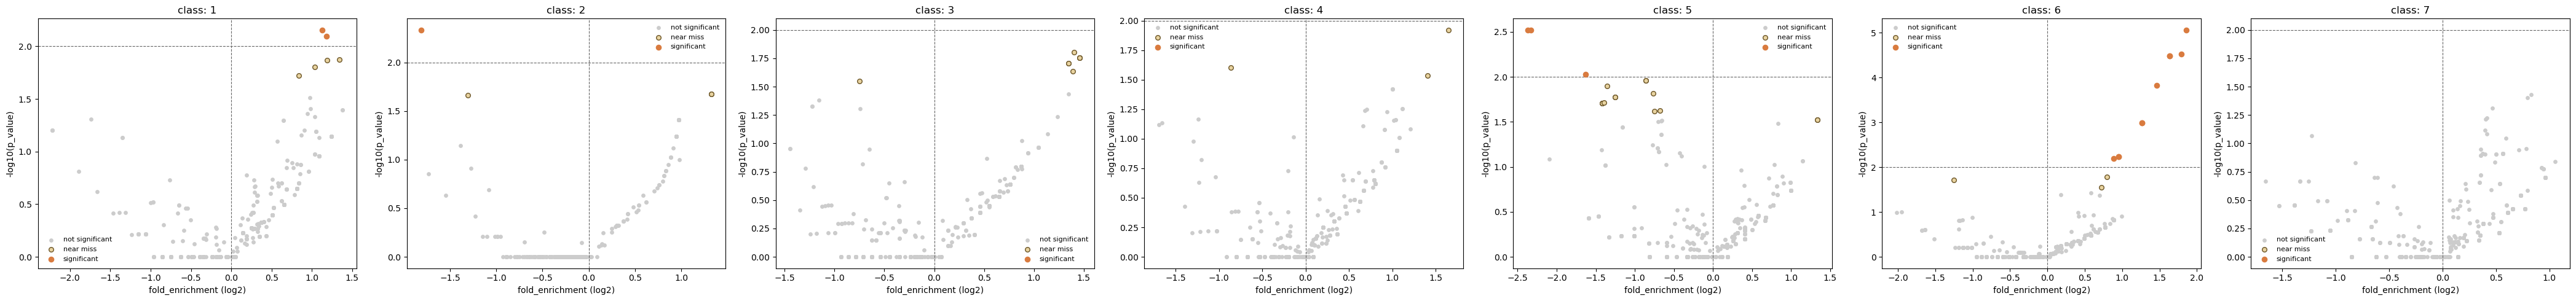

In [9]:
classes = sorted(df["class"].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls].copy()
    cls_df["neg_log10_p"] = -np.log10(cls_df["p_value"].clip(lower=1e-300))

    is_near_miss = (
        (~cls_df["significance"])
        & (cls_df[SIG_COL] >= SIG_THRESH)
        & (cls_df[SIG_COL] <= near_miss_upper)
    )
    not_sig = cls_df[~cls_df["significance"] & ~is_near_miss]
    near = cls_df[is_near_miss]
    sig = cls_df[cls_df["significance"]]

    ax.scatter(not_sig["fold_enrichment"], not_sig["neg_log10_p"],
               color="0.8", s=15, label="not significant", zorder=1)
    ax.scatter(near["fold_enrichment"], near["neg_log10_p"],
               color="#E8D3A0", edgecolor="#6B5527", s=30, label="near miss", zorder=2)
    ax.scatter(sig["fold_enrichment"], sig["neg_log10_p"],
               color="#D97B3F", s=35, label="significant", zorder=3)

    ax.axhline(-np.log10(SIG_THRESH), color="0.4", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
    ax.set_xlabel("fold_enrichment (log2)")
    ax.set_ylabel("-log10(p_value)")
    ax.set_title(f"class: {cls}")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Observed vs expected

A direct check on the raw counts behind each term, useful for catching
anything that looks structurally off (e.g. a population count of 0, which
should never happen since `run_ora` only tests terms with `n_pop > 0`).

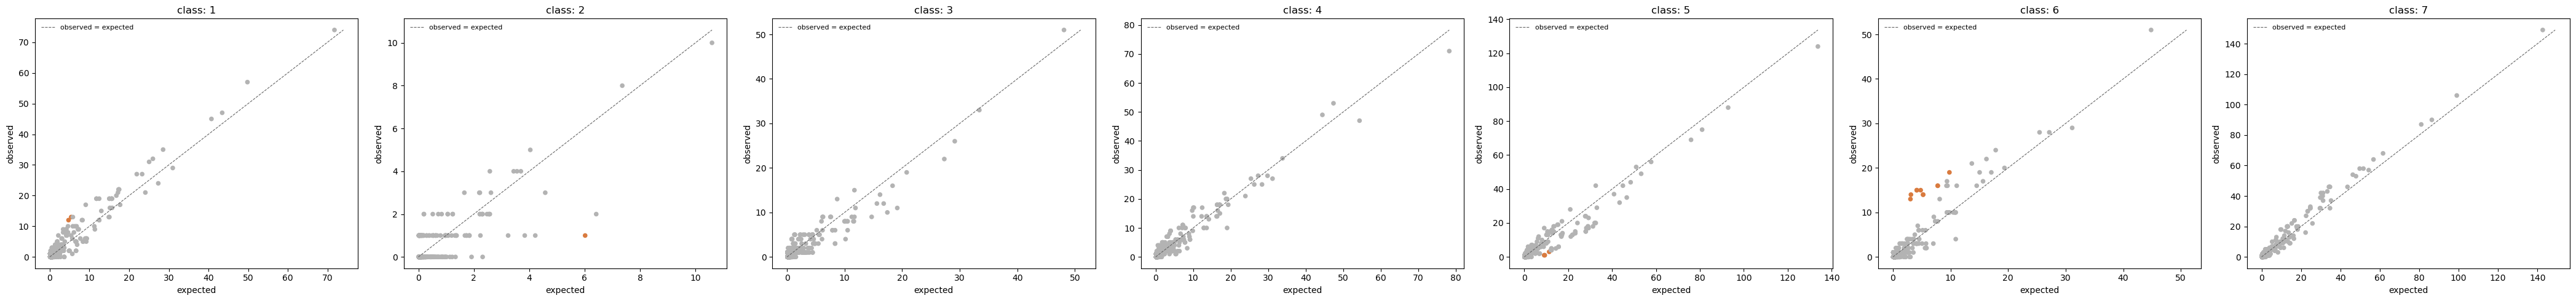

In [10]:
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls]
    colors = np.where(cls_df["significance"], "#D97B3F", "0.7")
    ax.scatter(cls_df["expected"], cls_df["observed"], c=colors, s=20)
    max_val = max(cls_df["expected"].max(), cls_df["observed"].max())
    ax.plot([0, max_val], [0, max_val], color="0.4", linestyle="--", linewidth=0.8,
            label="observed = expected")
    ax.set_xlabel("expected")
    ax.set_ylabel("observed")
    ax.set_title(f"class: {cls}")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## p-value distribution

A rough overall sanity check independent of any single term: under a null
with no real enrichment signal at all, p-values would be roughly uniform
across [0, 1]. A pileup near 0 suggests real signal; a pileup near 1 across
every class, with none near 0, would be a sign to double-check the run
rather than assume genuine absence of enrichment.

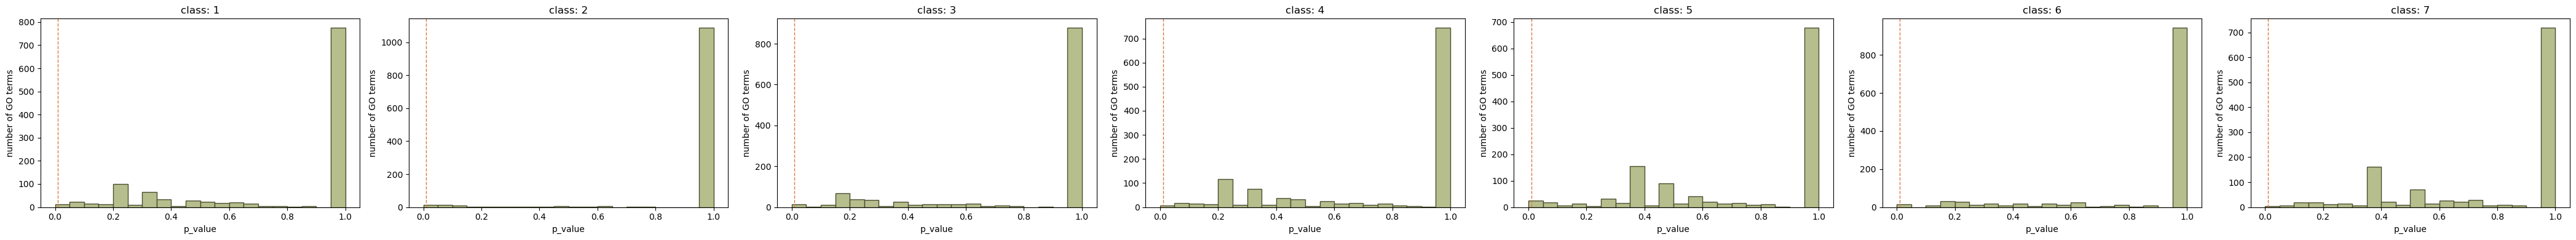

In [11]:
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 4), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls]
    ax.hist(cls_df["p_value"], bins=20, range=(0, 1), color="#B7BE8D", edgecolor="#4A4D2E")
    ax.axvline(SIG_THRESH, color="#D97B3F", linestyle="--", linewidth=1)
    ax.set_xlabel("p_value")
    ax.set_ylabel("number of GO terms")
    ax.set_title(f"class: {cls}")

fig.tight_layout()
plt.show()

## Comparison against a second run

Runs only if `RESULTS_ALL_TSV_COMPARE` is set. Intended for comparing the
same labeled genes against two different `.godb` files (e.g. full-GO vs
GO-slim), but works for any two result files that share `go_id`/`class`
values, e.g. two different labeling strategies on the same population.

602 (class, go_id) pairs present in both full-GO (8169 rows) and GO-slim (602 rows)


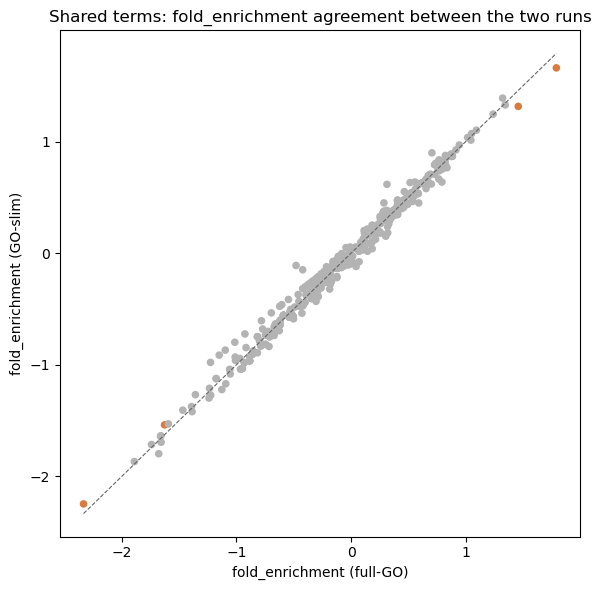


Significant in full-GO only: 1


,class,go_id,go_name_primary,p_value_primary,p_value_secondary
105,5,GO:0140657,ATP-dependent activity,0.009326,0.019802



Significant in GO-slim only: 0


In [12]:
if compare_df is not None:
    merged = df.merge(
        compare_df, on=["go_id", "class"], suffixes=("_primary", "_secondary"), how="inner"
    )
    print(f"{len(merged)} (class, go_id) pairs present in both "
          f"{COMPARE_LABEL_PRIMARY} ({len(df)} rows) and "
          f"{COMPARE_LABEL_SECONDARY} ({len(compare_df)} rows)")

    fig, ax = plt.subplots(figsize=(6, 6))
    colors = np.where(
        merged["significance_primary"] | merged["significance_secondary"],
        "#D97B3F", "0.7"
    )
    ax.scatter(merged["fold_enrichment_primary"], merged["fold_enrichment_secondary"],
               c=colors, s=20)
    lims = [
        min(merged["fold_enrichment_primary"].min(), merged["fold_enrichment_secondary"].min()),
        max(merged["fold_enrichment_primary"].max(), merged["fold_enrichment_secondary"].max()),
    ]
    ax.plot(lims, lims, color="0.4", linestyle="--", linewidth=0.8)
    ax.set_xlabel(f"fold_enrichment ({COMPARE_LABEL_PRIMARY})")
    ax.set_ylabel(f"fold_enrichment ({COMPARE_LABEL_SECONDARY})")
    ax.set_title("Shared terms: fold_enrichment agreement between the two runs")
    fig.tight_layout()
    plt.show()

    only_primary_sig = merged[merged["significance_primary"] & ~merged["significance_secondary"]]
    only_secondary_sig = merged[merged["significance_secondary"] & ~merged["significance_primary"]]
    print(f"\nSignificant in {COMPARE_LABEL_PRIMARY} only: {len(only_primary_sig)}")
    if len(only_primary_sig):
        display(only_primary_sig[["class", "go_id", "go_name_primary",
                                    "p_value_primary", "p_value_secondary"]])
    print(f"\nSignificant in {COMPARE_LABEL_SECONDARY} only: {len(only_secondary_sig)}")
    if len(only_secondary_sig):
        display(only_secondary_sig[["class", "go_id", "go_name_primary",
                                      "p_value_primary", "p_value_secondary"]])
else:
    print("RESULTS_ALL_TSV_COMPARE is not set, skipping comparison section.")

## Auto-generated plain-language summary

Templated, not hand-written per dataset -- reruns correctly for any input.
Uses the main README's mandated language ("tended to include", not
"statistically significant") since this threshold applies no
multiple-testing correction. Treat this as a first draft to edit, not a
final write-up.

In [13]:
for cls, cls_df in df.groupby("class"):
    sig_over = cls_df[cls_df["significance"] & (cls_df["fold_enrichment"] > 0)].sort_values("p_value")
    sig_under = cls_df[cls_df["significance"] & (cls_df["fold_enrichment"] < 0)].sort_values("p_value")

    print(f"Class '{cls}' ({len(cls_df)} terms tested):")
    if len(sig_over):
        names = ", ".join(sig_over["go_name"].head(5))
        print(f"  Genes in this class tended to include: {names}"
              f"{' (and others)' if len(sig_over) > 5 else ''}.")
    if len(sig_under):
        names = ", ".join(sig_under["go_name"].head(5))
        print(f"  Genes in this class tended to under-represent: {names}"
              f"{' (and others)' if len(sig_under) > 5 else ''}.")
    if not len(sig_over) and not len(sig_under):
        print(f"  No terms reached the significance threshold for this class.")
    print()

Class '1' (1167 terms tested):
  Genes in this class tended to include: kinase activity, phosphotransferase activity, alcohol group as acceptor.

Class '2' (1167 terms tested):
  Genes in this class tended to under-represent: cellular process.

Class '3' (1167 terms tested):
  No terms reached the significance threshold for this class.

Class '4' (1167 terms tested):
  No terms reached the significance threshold for this class.

Class '5' (1167 terms tested):
  Genes in this class tended to under-represent: structural constituent of ribosome, ribosome, ATP-dependent activity.

Class '6' (1167 terms tested):
  Genes in this class tended to include: structural constituent of ribosome, ribosome, translation, protein biosynthetic process, structural molecule activity (and others).

Class '7' (1167 terms tested):
  No terms reached the significance threshold for this class.



## Next steps

This notebook is exploration only, it never writes anything to disk. For
any GO ID, the full definition (not just name/namespace) can be looked up
at https://amigo.geneontology.org/amigo/term/<go_id>.